# PyTorch Workflow

Let's explore an example PyTorch end-to-end workflow.

Resources:
* Book: https://www.learnpytorch.io/01_pytorch_workflow/

In [109]:
what_were_covering = {1: "data (prepare and load)",
                      2: "build model",
                      3: "fitting the model to data (training)",
                      4: "making predictions and evaluating a model (inference)",
                      5: "saving and loading a model",
                      6: "putting it all together"}
what_were_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and evaluating a model (inference)',
 5: 'saving and loading a model',
 6: 'putting it all together'}

In [110]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.8.0+cu126'

## 1. Data preparing and loading

Data can be almost anything in machine learning

* Excel spreadsheet
* Images of any kind
* Videos (YouTube has lots of data)
* Audio like songs and podcasts
* DNA
* Text

Machine Learning is a game of two parts:
1. Get data  into a numerical representation
2. Build a model to learn patterns in that numerical repesentation

To showcase this, let's create some *known* data using the linear regression formula.

We'll use a linear regression formula to make a straight line with *known* **parameters**.

In [111]:
# Create known parameters
# y = wX + b
weight = 0.7
bias = 0.3

# create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim = 1)
# we added extra dimension to X to see it vertically
y = weight * X + bias
X[: 10], y[: 10], len(X), len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

### Splitting data into training and test sets (one of the most important concepts in machine learning in general)

Let's create a training and test set with our data

In [112]:
# Create a train/test split without using scikit learn library

train_split = int(0.8* len(X))
train_split

40

In [113]:
X_train, y_train = X[:train_split], y[: train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [114]:
X_train, y_train

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800],
         [0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800],
         [0.4000],
         [0.4200],
         [0.4400],
         [0.4600],
         [0.4800],
         [0.5000],
         [0.5200],
         [0.5400],
         [0.5600],
         [0.5800],
         [0.6000],
         [0.6200],
         [0.6400],
         [0.6600],
         [0.6800],
         [0.7000],
         [0.7200],
         [0.7400],
         [0.7600],
         [0.7800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260],
         [0.4400],
         [0.4540],
         [

How might we better visualize our data?

This is where the dat explorer's motto comes in!"Visualize, visualize, visualize!"


In [115]:
def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions = None):
  """
  Plots training data, test data and compares predictions
  """
  plt.figure(figsize = (10, 7))

  # plot training data in blue
  plt.scatter(train_data, train_labels, c = "b", s = 5, label = "Training data")

  # plot test data in green
  plt.scatter(test_data, test_labels, c = "g", s = 5, label = "Testing data")

  if predictions is not None:
    # plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c= "r", s = 5, label = "Predictions")

  # show the legend
  plt.legend(prop= {"size": 14})

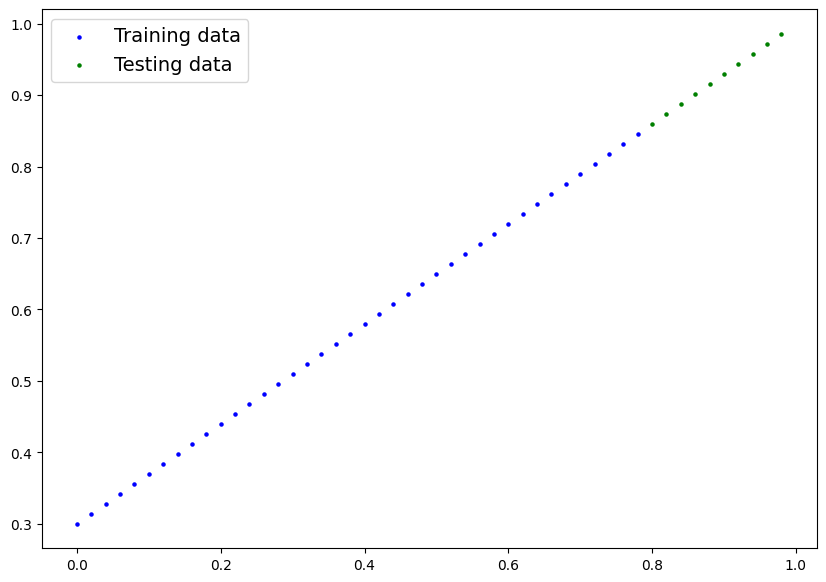

In [116]:
plot_predictions()

## 2. Build model

our first PyTorch model!

Resource to learn more about Python classes: https://realpython.com/python-classes/

nn module: https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html

What our model does:
* Start with random values (weight & bias)
* Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weight & bias values we used to create the data)

How does it do so?

Through two main algorithms:
1. Gradient descent - https://youtu.be/IHZwWFHWa-w
2. Backpropagation - https://youtu.be/Ilg3gGewQ5U

In [117]:
"""
class Parent:
    def __init__(self):
        print("Parent initialized")

class Child(Parent):
    def __init__(self):
        super().__init__()  # calls Parent.__init__()
        print("Child initialized")

obj = Child()

class MyModel(torch.nn.Module):
    def __init__(self):
        super().__init__()  # calls nn.Module.__init__()
        self.fc = torch.nn.Linear(10, 1)
If you don’t call super().__init__(), PyTorch won’t know about your
layers and things like .to(device) or .state_dict() will fail.
"""

'\nclass Parent:\n    def __init__(self):\n        print("Parent initialized")\n\nclass Child(Parent):\n    def __init__(self):\n        super().__init__()  # calls Parent.__init__()\n        print("Child initialized")\n\nobj = Child()\n\nclass MyModel(torch.nn.Module):\n    def __init__(self):\n        super().__init__()  # calls nn.Module.__init__()\n        self.fc = torch.nn.Linear(10, 1)\nIf you don’t call super().__init__(), PyTorch won’t know about your\nlayers and things like .to(device) or .state_dict() will fail.\n'

In [118]:
# Create a linear regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch inherits from nn.Module
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1, # <- start with random weight and try to adjust it to the ideal weight
                                            requires_grad= True, # <- can this parameter be updated via gradient descent?
                                            dtype = torch.float)) # <- PyTorch loves the datatype torch.float32?
    self.bias = nn.Parameter(torch.rand(1,  # <- start with random bias and try to adjust it to the ideal bias
                                        requires_grad= True,
                                        dtype = torch.float))
    # forward(): defines what happens when you call the model on some input.
    # forward method to define the computation in the model
  def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data
    return self.weights * x + self.bias # this is the linear regression formula


In the above cell, x is a placeholder (parameter) for whatever input you pass into the model.

When you later call:

model(X)


PyTorch automatically sends your big X tensor into the model’s forward() function, so inside that function, x actually refers to your X.

### PyTorch model building essentialsj:

* torch.nn - contains all of the buildings for computational graphs (a neural network can be considered a computational graph)

* torch.nn.Parameter - what parameters should our model try and learn, often a PyTorch layer from torch.nn will set these for us

* torch.nn.Module - The base class for all neural network modules, if you subclass it, you should overwrite forward()

* torch.optim - this where the optimizers in PyTorch live, they will help with gradient descent

* def forward() - All nn.Module subclasses require you to overwrite forward(), this method defines what happens in the forward computation

See more of these essential modules via the PyTorch cheatsheet - https://pytorch.org/tutorials/beginner/ptcheat.html

In [119]:
torch.manual_seed(42) # <- with manual seed it keeps generating the same value
torch.randn(1)

tensor([0.3367])

### Checking the contents of our PyTorch model
Now we've created a model, let's see what's inside...

So we can check our model parameters or what's inside our model using `.parameters().`

In [120]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

# Check out the para
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.3904], requires_grad=True)]

In [121]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.3904]))])

In [122]:
weight, bias

(0.7, 0.3)

the above two cells show what is the difference between the actual weight and bias and the random one that is generated. our goal is to make their difference (loss) as less as possible


### Making prediction using torch.inference_mode()
To check our model's predictive power, let's see how well it predicts `y_test` based on `X_test`.

When we pass data through our model, it's going to run it through the `forward()` method.

In [123]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

The ideal model will take the above `X_test` values and return `y_test` values

In [124]:
y_preds = model_0(X_test)
y_preds

tensor([[0.6598],
        [0.6665],
        [0.6733],
        [0.6800],
        [0.6867],
        [0.6935],
        [0.7002],
        [0.7069],
        [0.7137],
        [0.7204]], grad_fn=<AddBackward0>)

`with` runs a context manager

`inference` mode will turn off that gradient descent mode, because we don't need training and we don't need keep track of gradient descent

the result of the below cell is as same as the above cell

In [125]:
# Make predictions with model
with torch.inference_mode(): # inference == prediction, fit == training
  y_preds = model_0(X_test)

y_preds

tensor([[0.6598],
        [0.6665],
        [0.6733],
        [0.6800],
        [0.6867],
        [0.6935],
        [0.7002],
        [0.7069],
        [0.7137],
        [0.7204]])

In [126]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

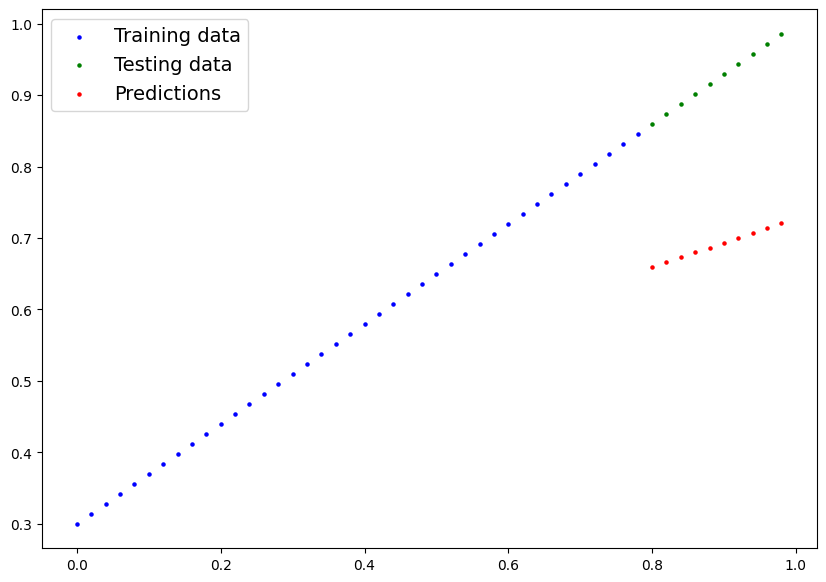

In [127]:
plot_predictions(predictions = y_preds)

the above result is quite bad, this is due to initializing the model with random parameter and it will gradually become better and better

In [128]:
# similar results with torch.no_grad() but inference_mode() is preferred
with torch.no_grad():
  y_preds = model_0(X_test)

y_preds

tensor([[0.6598],
        [0.6665],
        [0.6733],
        [0.6800],
        [0.6867],
        [0.6935],
        [0.7002],
        [0.7069],
        [0.7137],
        [0.7204]])


See more on inference mode here - https://twitter.com/PyTorch/status/1437838231505096708?s=20&t=cnKavO9iTgwQ-rfri6u7PQ


## 3. Train model
The whole idea of training is for a model to move from some unknown parameters (these may be random) to some known parameters.

Or in other words from a poor representation of the data to a better representation of the data.

One way to measure how poor or how wrong your models predictions are is to use a loss function.

* Note: Loss function may also be called cost function or criterion in different areas. For our case, we're going to refer to it as a loss function.

Things we need to train:

* **Loss function:** A function to measure how wrong your model's predictions are to the ideal outputs, lower is better.

* **Optimizer:** Takes into account the loss of a model and adjusts the model's parameters (e.g. weight & bias in our case) to improve the loss function - https://pytorch.org/docs/stable/optim.html#module-torch.optim

Inside the optimizer you'll often have to set two parameters:
* params - the model parameters you'd like to optimize, for example params=model_0.parameters()
* lr (learning rate) - the learning rate is a hyperparameter that defines how big/small the optimizer changes the parameters with each step (a small lr results in small changes, a large lr results in large changes)

And specifically for PyTorch, we need:

* A training loop
* A testing loop

In [129]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.3904], requires_grad=True)]

In [130]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.3904]))])

if we set lr to 0.1, in the above parameters for weight = 0.3367 it only takes 0.3, if we set it to 0.01 it takes 0.03, set to 0.001 it takes 0.006 and so on.

gradient descent:
new = 0.3367 - 0.3367* 0.01 = 0.333333

new1 = 0.333333 - 0.333333 * 0.01

and so on

In [131]:
# Setup a loss function
loss_fn = nn.L1Loss() # <- mean absolute error

# Setup an optimizer : Adam and Stochastic Gradient Descent (SGD) are the most famous one
# use optimizer to decrease error or improve loss (cost)
optimizer = torch.optim.SGD(params = model_0.parameters(), # <- weight and bias
                            lr= 0.01) # learning rate = possibly the most important hyperparameter you can get



**Q:** Which loss function and optimizer should I use?

**A:** This will be problem specific. But with experience, you'll get an idea of what works and what doesn't with your particular problem set.

For example, for a regression problem (like ours), a loss function of `nn.L1Loss()` and an optimizer like `torch.optim.SGD()` will suffice.

But for a classification problem like classifying whether a photo is of a dog or a cat, you'll likely want to use a loss function of `nn.BCELoss()` (binary cross entropy loss).

### Building a training loop (and a testing loop) in PyTorch

A couple of things we need in a training loop:

0. Loop through the data and do...
1. Forward pass (this involves data moving through our model's forward() functions) to make predictions on data - also called forward propagation
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backwards through the network to calculate the gradients of each of the parameters of our model with respect to the loss (**backpropagation** - https://www.youtube.com/watch?v=tIeHLnjs5U8)
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss (**gradient descent** - https://youtu.be/IHZwWFHWa-w)

in a simple word, gradient is *slop*, from uphill to downhill, we want to decrease loss.

In [132]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.3904], requires_grad=True)]

**optimizer.zero_grad():** In PyTorch, gradients accumulate by default, meaning that after each `loss.backward()`, the gradients are added to whatever was there before.

If you don’t clear them out first, you’d be mixing old and new gradients — which would make your weight updates incorrect.

everytime you run the above cell, also run the below cell. Loss will be decreased and weight and bias will get close to the actual values i.e. (0.7, 0.3).

if you define epochs = 1, you should run it manually 100 times to get to the least loss (ideally loss = 0). but you can set epochs to 100 and run it once, instead.

In [133]:
"""
torch.manual_seed(42)
# An epoch is one loop through the data (this is a hyperparameter because we set it ourselve)
epochs = 100

## Training
# 0. Loop through the data
for epoch in range(epochs):
  # set the model to training mode
  model_0.train() # train mode in PyTorch sets all parameters that require gradients to require gradients

  # 1. forward pass
  y_pred = model_0(X_train)

  # 2. calculate the loss function
  loss = loss_fn(y_pred, y_train)
  print(f"epoch {epoch+1}/{epochs} - loss: {loss.item():.6f}")

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward: perform backpropagation on the loss with respect to the parameters of the model
  loss.backward()

  # 5. Optimizer step: perform gradient descent
  optimizer.step() # by default how the optimizer changes will accumulate through the loop so
                   # we have to zero them above in step 3 for the next iteration of the loop

  ## Testing
  model_0.eval() # turns off gradient tracking like inference or no_grad which is not needed for evaluation
  with torch.inference_mode():
    # 1. Do the forward pass
    test_pred = model_0(X_test)

    # 2. calculate the loss
    test_loss = loss_fn(test_pred, y_test)

    # print out what is happening
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")

    # print out model state_dict()
    print(model_0.state_dict())
"""

'\ntorch.manual_seed(42)\n# An epoch is one loop through the data (this is a hyperparameter because we set it ourselve)\nepochs = 100\n\n## Training\n# 0. Loop through the data\nfor epoch in range(epochs):\n  # set the model to training mode\n  model_0.train() # train mode in PyTorch sets all parameters that require gradients to require gradients\n\n  # 1. forward pass\n  y_pred = model_0(X_train)\n\n  # 2. calculate the loss function\n  loss = loss_fn(y_pred, y_train)\n  print(f"epoch {epoch+1}/{epochs} - loss: {loss.item():.6f}")\n\n  # 3. Optimizer zero grad\n  optimizer.zero_grad()\n\n  # 4. Loss backward: perform backpropagation on the loss with respect to the parameters of the model\n  loss.backward()\n\n  # 5. Optimizer step: perform gradient descent\n  optimizer.step() # by default how the optimizer changes will accumulate through the loop so\n                   # we have to zero them above in step 3 for the next iteration of the loop\n\n  ## Testing\n  model_0.eval() # turns o

In [134]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.3904]))])

In [135]:
weight, bias

(0.7, 0.3)

In [136]:
torch.manual_seed(42)
# An epoch is one loop through the data (this is a hyperparameter because we set it ourselve)
epochs = 200

# Track different values
epoch_count = []
loss_values = []
test_loss_values = []

## Training
# 0. Loop through the data
for epoch in range(epochs):
  # set the model to training mode
  model_0.train() # train mode in PyTorch sets all parameters that require gradients to require gradients

  # 1. forward pass
  y_pred = model_0(X_train)

  # 2. calculate the loss function
  loss = loss_fn(y_pred, y_train)
  print(f"epoch {epoch+1}/{epochs} - loss: {loss.item():.6f}")

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward: perform backpropagation on the loss with respect to the parameters of the model
  loss.backward()

  # 5. Optimizer step: perform gradient descent
  optimizer.step() # by default how the optimizer changes will accumulate through the loop so
                   # we have to zero them above in step 3 for the next iteration of the loop

  ## Testing
  model_0.eval() # turns off gradient tracking like inference or no_grad which is not needed for evaluation
  with torch.inference_mode():
    # 1. Do the forward pass
    test_pred = model_0(X_test)

    # 2. calculate the loss
    test_loss = loss_fn(test_pred, y_test)

    # print out what is happening
  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)

    print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")

    # print out model state_dict()
    print(model_0.state_dict())

epoch 1/200 - loss: 0.081696
Epoch: 0 | Loss: 0.08169572055339813 | Test loss: 0.22662055492401123
OrderedDict({'weights': tensor([0.3398]), 'bias': tensor([0.3939])})
epoch 2/200 - loss: 0.079512
epoch 3/200 - loss: 0.077718
epoch 4/200 - loss: 0.075963
epoch 5/200 - loss: 0.074525
epoch 6/200 - loss: 0.073108
epoch 7/200 - loss: 0.071979
epoch 8/200 - loss: 0.070850
epoch 9/200 - loss: 0.069822
epoch 10/200 - loss: 0.068952
epoch 11/200 - loss: 0.068081
Epoch: 10 | Loss: 0.06808149069547653 | Test loss: 0.1807345449924469
OrderedDict({'weights': tensor([0.3672]), 'bias': tensor([0.4154])})
epoch 12/200 - loss: 0.067326
epoch 13/200 - loss: 0.066665
epoch 14/200 - loss: 0.066003
epoch 15/200 - loss: 0.065401
epoch 16/200 - loss: 0.064897
epoch 17/200 - loss: 0.064392
epoch 18/200 - loss: 0.063888
epoch 19/200 - loss: 0.063384
epoch 20/200 - loss: 0.062984
epoch 21/200 - loss: 0.062584
Epoch: 20 | Loss: 0.06258393079042435 | Test loss: 0.15627031028270721
OrderedDict({'weights': tensor

In [137]:
import numpy as np
# convert tensor values to numpy array
np.array(torch.tensor(loss_values).cpu().numpy()), test_loss_values

(array([0.08169572, 0.06808149, 0.06258393, 0.05879194, 0.05530194,
        0.05182225, 0.04838594, 0.04494876, 0.04152032, 0.03808232,
        0.03464684, 0.03121751, 0.02777871, 0.0243449 , 0.0209139 ,
        0.01747509, 0.01404297, 0.01061027, 0.00717147, 0.00374104],
       dtype=float32),
 [tensor(0.2266),
  tensor(0.1807),
  tensor(0.1563),
  tensor(0.1419),
  tensor(0.1308),
  tensor(0.1205),
  tensor(0.1122),
  tensor(0.1046),
  tensor(0.0964),
  tensor(0.0881),
  tensor(0.0805),
  tensor(0.0722),
  tensor(0.0640),
  tensor(0.0564),
  tensor(0.0481),
  tensor(0.0398),
  tensor(0.0323),
  tensor(0.0240),
  tensor(0.0157),
  tensor(0.0081)])

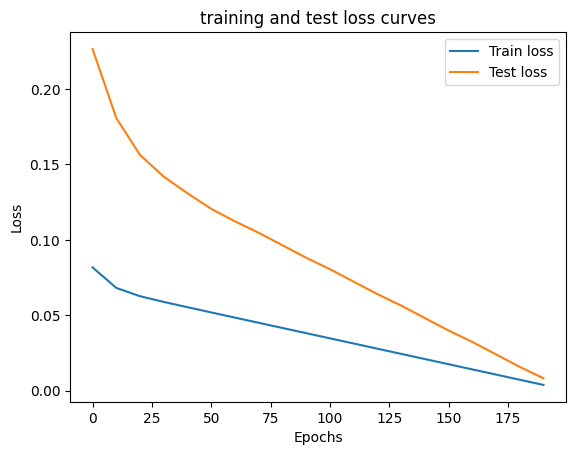

In [138]:
# plot the loss curves
plt.plot(epoch_count, np.array(torch.tensor(loss_values).cpu().numpy()), label = "Train loss")
plt.plot(epoch_count, test_loss_values, label = "Test loss")
plt.title("training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

In [139]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)

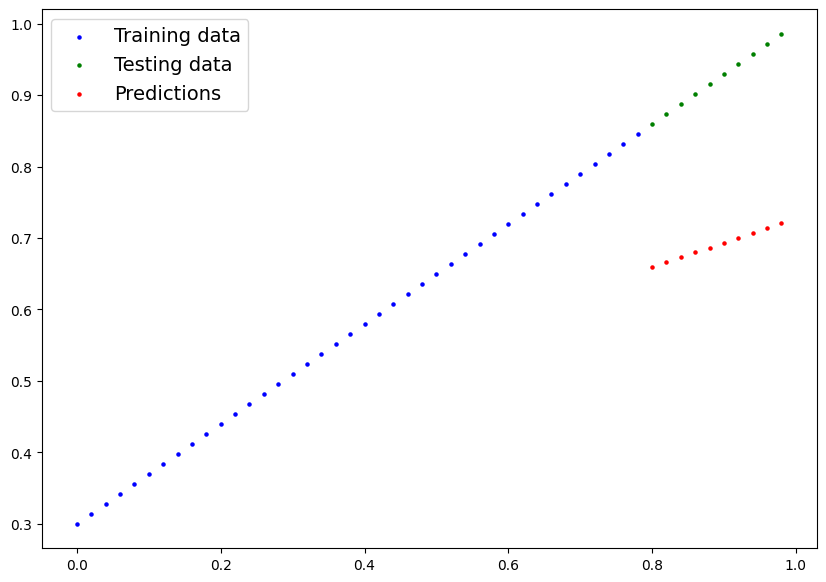

In [140]:
plot_predictions(predictions=y_preds)

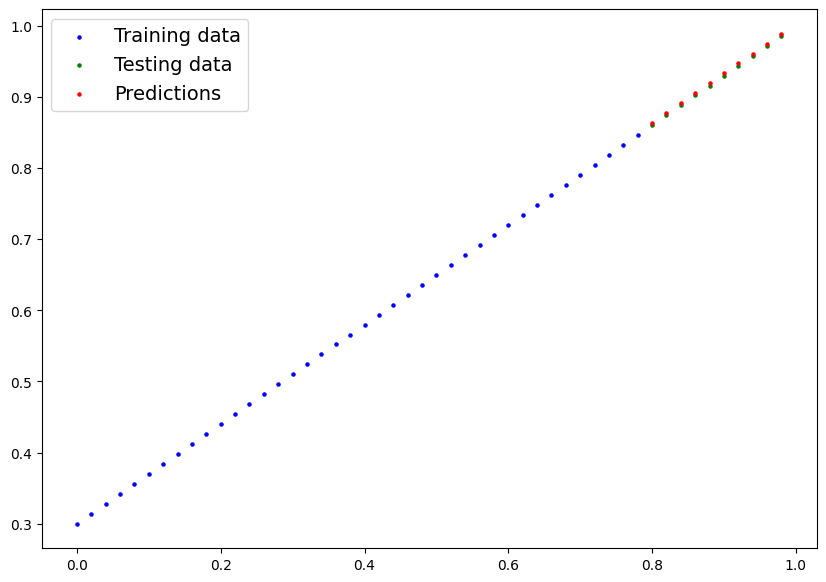

In [141]:
plot_predictions(predictions=y_preds_new)

## Saving a model in PyTorch

There are three main methods you should about for saving and loading models in PyTorch.

1. `torch.save()` - allows you save a PyTorch object in Python's pickle format
2. `torch.load()` - allows you load a saved PyTorch object
3. `torch.nn.Module.load_state_dict()` - this allows to load a model's saved state dictionary

PyTorch save & load code tutorial + extra-curriculum - https://pytorch.org/tutorials/beginner/saving_loading_models.html#saving-loading-model-for-inference

In [142]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6962])), ('bias', tensor([0.3064]))])

In [143]:
# Saving our PyTorch model
from pathlib import Path

# 1. Create a model directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True, exist_ok = True)

# 2. Create a model save path
MODEL_NAME = "01_pytorch_workflow_model.pth" #<- .pt or .pth are PyTorch file extension
MODEL_SAVE_PATH= MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj = model_0.state_dict(), # <- same as model.state_dict()
           f = MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model.pth


Now if you open the folder named models in Colab (the left side) you will see the saved file.

In [144]:
!ls -l models

total 4
-rw-r--r-- 1 root root 2101 Oct 17 11:34 01_pytorch_workflow_model.pth



##Loading a PyTorch model

Since we saved our model's `state_dict()` rather the entire model, we'll create a new instance of our model class and load the saved `state_dict()` into that.

In [145]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6962])), ('bias', tensor([0.3064]))])

In [147]:
# To load in a saved state_dict we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

# Load the saved state_dict of model_0 (this will update the new instance with updated parameters)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [148]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6962])), ('bias', tensor([0.3064]))])

In [149]:
# Make some predictions with our loaded model
loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8634],
        [0.8773],
        [0.8913],
        [0.9052],
        [0.9191],
        [0.9330],
        [0.9469],
        [0.9609],
        [0.9748],
        [0.9887]])

In [151]:
# make some models preds
model_0.eval()
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[0.8634],
        [0.8773],
        [0.8913],
        [0.9052],
        [0.9191],
        [0.9330],
        [0.9469],
        [0.9609],
        [0.9748],
        [0.9887]])

In [152]:
# compare loaded model preds with original model preds
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])